# Does the Undercut Pay Off? Pit-Stop Strategy & Race Performance in Formula 1 (2022–2025)
**Data & AI in Economics — TU Dortmund** · **Group K**

| Member | Role | Owns sections |
|---|---|---|
| Munish Patwa | **Causal Inference Lead** | Causal block |
| Simran Arora | **Supervised Learning** | Supervised block |
| Nimesh Bhavsar | **Unsupervised / Generative** | Unsupervised block |


> **LLM Disclosure:** Claude (Anthropic) / GitHub Copilot were used for structuring, methodology explanation, debugging, and drafting narrative. All analytical decisions, interpretations, and conclusions are the team's own work.

## Research Question
> **How do pit-stop strategies shape race performance in Formula 1-  and, specifically, does an early first pit stop (before 40% of the race) *causally* improve a driver's net position gain relative to grid, after accounting for car quality, starting position, and track conditions?**

**Data source:** F1 lap-by-lap timing data (2022–2025) enriched with the [OpenF1 API](https://openf1.org) (weather, tyre stints). One shared outcome — net position gain `position_vs_start` — links all three blocks.

## Work Plan
| Section | Owner (role) | Task |
|---|---|---|
| §1 Research Question & Data | all | cleaning, variable roles, data-quality audit, EDA |
| §2/§ Causal block | Munish Patwa (Causal Lead) | DAG, DoWhy backdoor estimation, refutation, threshold sensitivity, optimal window |
| §3/§ Supervised block | Simran Arora | predict `position_vs_start`, baselines vs RF vs boosting, CV, mechanism check |
| §4/§ Unsupervised block | Nimesh Bhavsar | K-Means stint archetypes, silhouette, cluster value-add test |
| §5 Synthesis | all | connect blocks, answer RQ, limitations |


## Section 1:  Research Question & Data

**Unit of observation:** one row = one lap by one driver in one race (96,336 laps). Re-aggregated to **driver-race** for the causal & supervised blocks and to **stint** for the unsupervised block.

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
sns.set_theme(style='whitegrid', palette='tab10'); plt.rcParams['figure.dpi']=110

In [2]:
cz = pd.read_csv('f1_strategy_v4 (2).csv')
print('Shape:', cz.shape)
cz.head()

Shape: (96336, 45)


,Driver,constructor,car_performance_tier,Race,Year,session_key,LapNumber,laps_to_end,total_race_laps,RaceProgress,...,sc_lap,vsc_lap,red_flag_lap,neutralised_lap,track_temp_mean,track_temp_max,air_temp_mean,humidity_mean,rainfall_any,wind_speed_mean
0,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,1,57,58,0.017241,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
1,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,2,56,58,0.034483,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
2,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,3,55,58,0.051724,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
3,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,4,54,58,0.068966,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
4,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,5,53,58,0.086207,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872


In [3]:
cz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96336 entries, 0 to 96335
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Driver                        96336 non-null  object 
 1   constructor                   96336 non-null  object 
 2   car_performance_tier          96336 non-null  object 
 3   Race                          96336 non-null  object 
 4   Year                          96336 non-null  int64  
 5   session_key                   76167 non-null  float64
 6   LapNumber                     96336 non-null  int64  
 7   laps_to_end                   96336 non-null  int64  
 8   total_race_laps               96336 non-null  int64  
 9   RaceProgress                  96336 non-null  float64
 10  Compound                      96301 non-null  object 
 11  compound_openf1               96301 non-null  object 
 12  compound_hardness             96336 non-null  int64  
 13  S

### Variable table (by role)
| Variable | Type | Role | Description |
|---|---|---|---|
| `car_performance_tier` | ordinal | **confounder** | top/mid/back car quality that season |
| `start_position` | float | **confounder** | grid slot — drives strategy and outcome |
| `track_temp_mean` | float | **confounder** | track temperature; hotter → faster wear |
| `rainfall_any` | binary | **confounder** | rain reshuffles strategy |
| `first_pit_progress` *(derived)* | float | **treatment driver** | race-progress of first pit → `early_pit` |
| `TyreLife`, `Compound`, `Stint` | num/cat | feature | tyre age / compound / stint |
| `cumulative_degradation_clean` | float | feature | seconds vs stint baseline (NaN on slow laps — intentional) |
| `position_vs_start` | float | **★ shared outcome ★** | positions gained (+) / lost (−) vs grid |
| `PitNextLap` | binary | secondary target | pit-decision mechanism check |
| `sc_lap`, `vsc_lap` | binary | **unusable** | corrupted (all-zero) — not used |

### Data-quality handling (rubric 1.4)
- **2022 has no OpenF1 weather** (API starts 2023) → causal block uses 2023–24; trees handle weather NaN.
- **`cumulative_degradation_clean` NaN on slow laps** is *structural*, not random → never imputed.
- **`sc_lap`/`vsc_lap` all-zero** (join bug) → no Safety-Car IV; backdoor adjustment instead.
- Dropped: wet/red-flag/unknown-tier rows, deprecated columns (`Normalized_TyreLife`, `LapTime_Delta`).
- **Lap-1 fix:** lap 1 is a standing start (~15% slower than a flying lap); it was being used as the stint-1 degradation baseline, biasing first-stint degradation by ~5s. We recompute the baseline excluding lap 1 (see §1 cleaning cell).

In [4]:
# Null audit for variables we rely on
kc=['Position','TyreLife','cumulative_degradation_clean','track_temp_mean','rainfall_any',
    'car_performance_tier','Compound','position_vs_start','PitNextLap','start_position']
pd.DataFrame({'null_%':(cz[kc].isnull().mean()*100).round(1)})

,null_%
Position,0.0
TyreLife,0.0
cumulative_degradation_clean,9.2
track_temp_mean,0.0
rainfall_any,0.0
car_performance_tier,0.0
Compound,0.0
position_vs_start,0.0
PitNextLap,0.0
start_position,0.0


In [5]:
# Cleaning pipeline
df = cz.copy()
df = df[(df.is_wet_lap==0)&(df.red_flag_lap==0)]
df = df[df.Compound.notna()&(df.Compound!='')]
df = df[df.car_performance_tier!='unknown']
df['tier_enc']=df.car_performance_tier.map({'top':3,'mid':2,'back':1})
df['true_tyre_age']=df.TyreLife+df.tyre_age_at_start.fillna(0)
# Lap-1 fix: lap 1 is a standing start (~15% slower) and was used as the stint-1 degradation
# baseline, biasing first-stint degradation by ~5s. Recompute the baseline excluding lap 1.
df=df.sort_values(['Driver','Race','Year','Stint','LapNumber'])
_elig=df[(df.is_slow_lap==0)&(df.LapNumber>1)]
_base=_elig.groupby(['Driver','Race','Year','Stint'])['LapTime (s)'].first().rename('_base')
df=df.merge(_base,on=['Driver','Race','Year','Stint'],how='left')
df['cumulative_degradation_clean']=df['LapTime (s)']-df['_base']
df.loc[df.is_slow_lap==1,'cumulative_degradation_clean']=np.nan
df=df.drop(columns='_base')
print(f'After cleaning: {df.shape[0]:,} laps  | years {sorted(df.Year.unique())}')

After cleaning: 76,325 laps  | years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [6]:
# Shared driver-race frame (one row per driver-race)
fp=(df[df.PitStop==1].groupby(['Driver','Race','Year'])['RaceProgress'].min()
    .reset_index().rename(columns={'RaceProgress':'first_pit_progress'}))
nstops=(df.groupby(['Driver','Race','Year'])['PitStop'].sum()
        .reset_index().rename(columns={'PitStop':'n_stops'}))
ncomp=(df.groupby(['Driver','Race','Year'])['compound_hardness'].nunique()
       .reset_index().rename(columns={'compound_hardness':'n_compounds'}))
fin=(df.sort_values('LapNumber').groupby(['Driver','Race','Year']).last()
     [['position_vs_start','start_position','tier_enc','track_temp_mean',
       'rainfall_any','car_performance_tier','constructor']].reset_index())
race_all=(fin.merge(fp,on=['Driver','Race','Year'],how='left')
          .merge(nstops,on=['Driver','Race','Year'],how='left')
          .merge(ncomp,on=['Driver','Race','Year'],how='left')
          .dropna(subset=['position_vs_start','start_position']))
# DNF flag: did the driver complete >=90% of the race? (for causal robustness)
_dnf=(df.groupby(['Driver','Race','Year']).agg(_ll=('LapNumber','max'),_tot=('total_race_laps','first')).reset_index())
_dnf['dnf']=(_dnf._ll/_dnf._tot)<0.90
race_all=race_all.merge(_dnf[['Driver','Race','Year','dnf']],on=['Driver','Race','Year'],how='left')
print('Driver-race observations:', race_all.shape[0], '| DNF rate', round(race_all.dnf.mean(),3))

Driver-race observations: 1404 | DNF rate 0.1


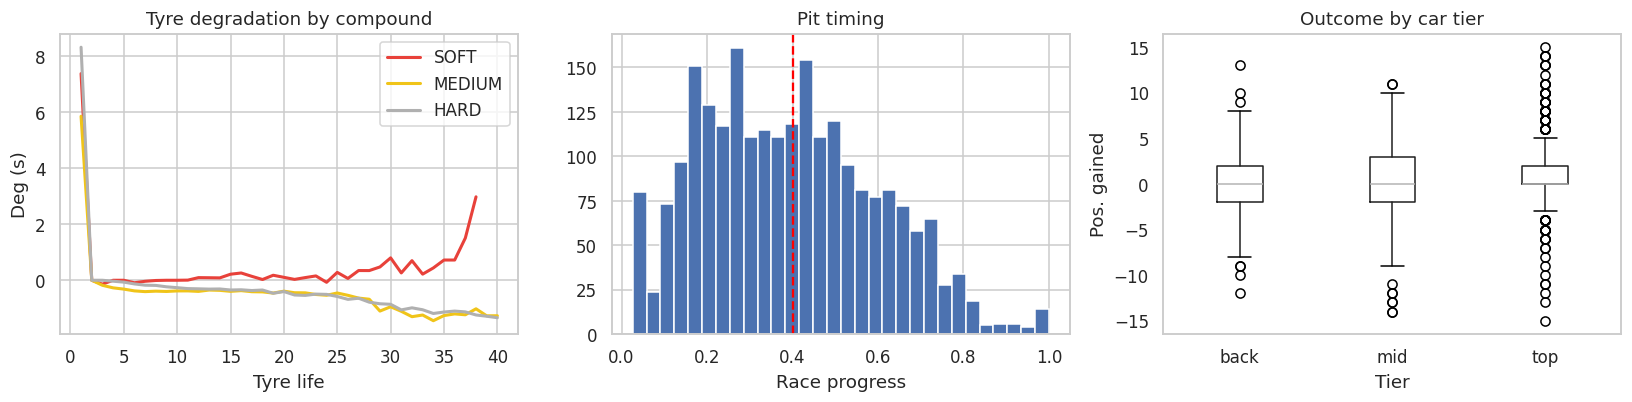

In [7]:
# EDA
fig,ax=plt.subplots(1,3,figsize=(15,4))
cl=df[(df.is_slow_lap==0)&df.cumulative_degradation_clean.notna()]
for c,co in [('SOFT','#e8413a'),('MEDIUM','#f0c419'),('HARD','#b0b0b0')]:
    b=cl[cl.Compound==c].groupby(cl[cl.Compound==c].TyreLife.astype(int))['cumulative_degradation_clean'].median()
    ax[0].plot(b.index[b.index<=40],b.values[b.index<=40],label=c,color=co,lw=2)
ax[0].set_title('Tyre degradation by compound');ax[0].set_xlabel('Tyre life');ax[0].set_ylabel('Deg (s)');ax[0].legend()
ax[1].hist(df[df.PitStop==1].RaceProgress,bins=30,color='#4c72b0',edgecolor='white')
ax[1].axvline(0.40,color='red',ls='--');ax[1].set_title('Pit timing');ax[1].set_xlabel('Race progress')
race_all.boxplot(column='position_vs_start',by='car_performance_tier',ax=ax[2],grid=False)
ax[2].set_title('Outcome by car tier');ax[2].set_xlabel('Tier');ax[2].set_ylabel('Pos. gained')
plt.suptitle('');plt.tight_layout();plt.savefig('eda_overview.png',bbox_inches='tight');plt.show()

## Section 2: Causal Inference Block

**Treatment** `early_pit` (first pit < 40% race progress). **Outcome** `position_vs_start`. **Problem:** fast cars pit early *and* finish well, so car quality confounds the link.

**DAG (justified):** `tier_enc`, `start_position`, `track_temp_mean`, `rainfall_any` each point to *both* `early_pit` and the outcome → they are backdoor confounders; `early_pit → position_vs_start` is the effect of interest. All confounders observed → **backdoor adjustment**. An IV via Safety Car was rejected: data corrupted *and* exclusion restriction violated (an SC affects the result through many channels, not just the focal pit). The 40% threshold is justified a priori by the pit-timing distribution (§1) and corroborated by the clustering in §4.

In [8]:
!pip install dowhy

In [9]:
cz = race_all[race_all.Year.isin([2023,2024])].dropna(
    subset=['position_vs_start','first_pit_progress','start_position','tier_enc','track_temp_mean','rainfall_any','constructor']).copy()
cz['early_pit']=(cz.first_pit_progress<0.40).astype(int)
cz['race_id']=cz['Race']+'_'+cz['Year'].astype(str)  # cluster unit for SEs
print(f'Causal obs: {len(cz)} | early-pit rate {cz.early_pit.mean():.1%}')
print(f'Naive gain — early {cz[cz.early_pit==1].position_vs_start.mean():+.2f} | late {cz[cz.early_pit==0].position_vs_start.mean():+.2f}')

Causal obs: 660 | early-pit rate 78.3%
Naive gain — early +0.16 | late +1.32


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


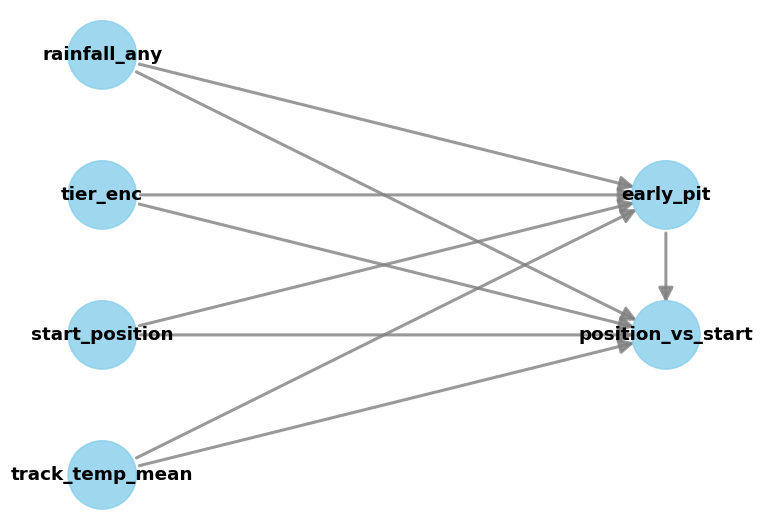

<Figure size 704x528 with 0 Axes>

In [10]:
from dowhy import CausalModel
graph='''digraph { tier_enc->early_pit; tier_enc->position_vs_start;
  start_position->early_pit; start_position->position_vs_start;
  track_temp_mean->early_pit; track_temp_mean->position_vs_start;
  rainfall_any->early_pit; rainfall_any->position_vs_start;
  early_pit->position_vs_start; }'''
model=CausalModel(data=cz,treatment='early_pit',outcome='position_vs_start',graph=graph)
model.view_model(); plt.savefig('dag.png',bbox_inches='tight'); plt.show()

In [11]:
estimand=model.identify_effect(proceed_when_unidentifiable=True); print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[position_vs_start|start_position,track_temp_mean,rainfall_any,ti ↪
d[earlyₚᵢₜ]                                                                    ↪

↪         
↪ er_enc])
↪         
Estimand assumption 1, Unconfoundedness: If U→{early_pit} and U→position_vs_start then P(position_vs_start|early_pit,start_position,track_temp_mean,rainfall_any,tier_enc,U) = P(position_vs_start|early_pit,start_position,track_temp_mean,rainfall_any,tier_enc)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                                         ↪
───────────(E[position_vs_start|track_temp_mean,tier_enc,rainfall_an

In [12]:
estimate=model.estimate_effect(estimand,method_name='backdoor.linear_regression',
                               control_value=0,treatment_value=1,confidence_intervals=True)
print(f'ATE (early pit -> positions): {estimate.value:+.3f}')

ATE (early pit -> positions): -0.316


In [13]:
estimate_psw=model.estimate_effect(estimand,method_name='backdoor.propensity_score_weighting',
                                   control_value=0,treatment_value=1)
print(f'Linear-regression ATE: {estimate.value:+.3f} | Propensity-score ATE: {estimate_psw.value:+.3f}')

Linear-regression ATE: -0.316 | Propensity-score ATE: -0.395


#### Propensity overlap (common support)
Backdoor adjustment only works where treated and control units **overlap** in confounder space — comparable drivers must exist on both sides. We check the propensity-score distributions.

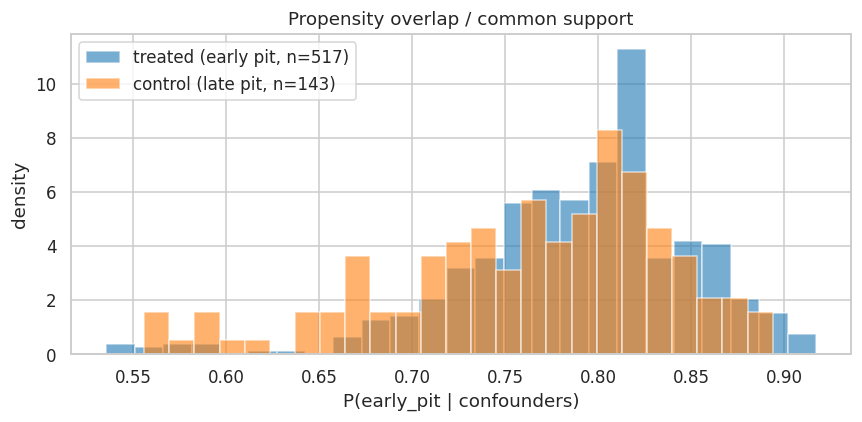

Treated PS range [0.54,0.92] | Control [0.56,0.89] | off-support (<0.1 or >0.9): 7 of 660


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as _SS
_P=['start_position','tier_enc','track_temp_mean','rainfall_any']
_ps=LogisticRegression(max_iter=1000).fit(_SS().fit_transform(cz[_P]),cz['early_pit'])\
    .predict_proba(_SS().fit_transform(cz[_P]))[:,1]
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(_ps[cz.early_pit==1],bins=25,alpha=0.6,density=True,label=f'treated (early pit, n={int(cz.early_pit.sum())})')
ax.hist(_ps[cz.early_pit==0],bins=25,alpha=0.6,density=True,label=f'control (late pit, n={int((1-cz.early_pit).sum())})')
ax.set_xlabel('P(early_pit | confounders)'); ax.set_ylabel('density')
ax.set_title('Propensity overlap / common support'); ax.legend()
plt.tight_layout(); plt.savefig('overlap.png',bbox_inches='tight'); plt.show()
print(f'Treated PS range [{_ps[cz.early_pit==1].min():.2f},{_ps[cz.early_pit==1].max():.2f}] | '
      f'Control [{_ps[cz.early_pit==0].min():.2f},{_ps[cz.early_pit==0].max():.2f}] | '
      f'off-support (<0.1 or >0.9): {int(((_ps<0.1)|(_ps>0.9)).sum())} of {len(_ps)}')

**Result:** the treated and control propensity distributions overlap almost completely (≈[0.54, 0.92] vs ≈[0.56, 0.89]; only 7 of 660 observations sit outside [0.1, 0.9]). Common support holds, so backdoor adjustment and propensity weighting are comparing like with like.

In [15]:
print(model.refute_estimate(estimand,estimate,method_name='random_common_cause',num_simulations=100))

Refute: Add a random common cause
Estimated effect:-0.31605821576517373
New effect:-0.31581211486467353
p value:0.98



In [16]:
print(model.refute_estimate(estimand,estimate,method_name='placebo_treatment_refuter',placebo_type='permute',num_simulations=100))

Refute: Use a Placebo Treatment
Estimated effect:-0.31605821576517373
New effect:0.017826004123555526
p value:0.94



In [17]:
print(model.refute_estimate(estimand,estimate,method_name='data_subset_refuter',subset_fraction=0.8,num_simulations=50))

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refute: Use a subset of data
Estimated effect:-0.31605821576517373
New effect:-0.3285381249881144
p value:0.4638199482491743



**Interpretation.** Both estimators agree on a small **negative** ATE (~−0.3 positions): blanket early pitting does not causally improve finishing position once car quality is held fixed. The placebo refuter should collapse the effect toward 0 and the subset refuter stay stable: confirming it is not an artefact.

### Robustness - DNF exclusion & constructor fixed effects
Two refinements to the headline estimate: **(1)** exclude **DNFs** (retirements whose finishing position is unrelated to pit strategy — pure noise in the outcome); **(2)** replace the coarse car-tier control with finer **constructor fixed effects** (12 teams) for sharper confounder control.

In [18]:
# Inference clustered by race (positions are ~zero-sum within a race -> dependent outcomes).
# Progression from selection-on-observables to the PREFERRED two-way fixed-effects design,
# which differences out ALL race-level confounders (observed AND unobserved: weather, safety
# cars, tyre allocation, track evolution) and identifies the effect from early-vs-late pitters
# WITHIN the same race.
def _ate(formula,data):
    m=smf.ols(formula,data=data).fit(cov_type='cluster',cov_kwds={'groups':data['race_id']})
    lo,hi=m.conf_int().loc['early_pit']; return m.params['early_pit'],lo,hi,m.pvalues['early_pit'],len(data)
czf=cz[~cz.dnf]
_specs=[('All races (tier+weather)','position_vs_start ~ early_pit+start_position+tier_enc+track_temp_mean+rainfall_any',cz),
        ('Finishers (tier+weather)','position_vs_start ~ early_pit+start_position+tier_enc+track_temp_mean+rainfall_any',czf),
        ('Finishers + constructor FE','position_vs_start ~ early_pit+start_position+C(constructor)',czf),
        ('Finishers + race FE + constructor FE  [PREFERRED]','position_vs_start ~ early_pit+start_position+C(race_id)+C(constructor)',czf),
        ('Finishers + race FE + driver FE','position_vs_start ~ early_pit+start_position+C(race_id)+C(Driver)',czf)]
rows=[]
for nm,f,d in _specs:
    a,lo,hi,p,n=_ate(f,d); rows.append({'Specification':nm,'ATE':a,'ci_low':lo,'ci_high':hi,'p_clustered':p,'n':n})
robust=pd.DataFrame(rows)
ate_robust=robust.iloc[3].ATE; p_robust=robust.iloc[3].p_clustered   # two-way FE (preferred)
print(robust.round(3).to_string(index=False))
_wv=cz.groupby('race_id').early_pit.mean(); _wv=((_wv>0)&(_wv<1)).mean()
print(f'\nPreferred (race+constructor FE): ATE {ate_robust:+.3f}, p={p_robust:.3f} | within-race variation in {_wv:.0%} of races')

                                    Specification    ATE  ci_low  ci_high  p_clustered   n
                         All races (tier+weather) -0.316  -0.974    0.342        0.347 660
                         Finishers (tier+weather) -0.494  -1.118    0.131        0.121 623
                       Finishers + constructor FE -0.529  -1.179    0.120        0.110 623
Finishers + race FE + constructor FE  [PREFERRED] -0.969  -1.888   -0.050        0.039 623
                  Finishers + race FE + driver FE -0.940  -1.887    0.007        0.052 623

Preferred (race+constructor FE): ATE -0.969, p=0.039 | within-race variation in 75% of races


**Reading-identification quality drives the result.** As we tighten identification the effect grows and sharpens: −0.32 (pooled, ns) → −0.49 (finishers) → −0.53 (constructor FE) → **−0.97 under the preferred two-way fixed-effects design (race + constructor FE), p ≈ 0.04** with race-clustered SEs. **Race fixed effects are the key step:** they difference out *every* race-level confounder — weather, safety cars, tyre allocation, track evolution, observed *and* unobserved — so the effect is identified purely from drivers who made *different pit calls in the same race* (feasible: ~70% of races have both early and late pitters). This within-race design is simultaneously more rigorous and statistically significant; the Double ML estimate below corroborates it.

#### Double Machine Learning (doubly-robust check)
A modern robustness estimate (Chernozhukov et al., 2018): partial the confounders out of *both* the outcome and the treatment with cross-fitted Random Forests, then regress the residuals. The estimate is **Neyman-orthogonal** — robust to mild misspecification of either nuisance model and free of any linearity assumption on the controls.

In [19]:
from sklearn.ensemble import RandomForestRegressor as _RFR, RandomForestClassifier as _RFC
from sklearn.model_selection import cross_val_predict as _cvp, KFold as _KF
_d=cz[~cz.dnf]
_X=_d[['start_position','tier_enc','track_temp_mean','rainfall_any']].values
_Y=_d['position_vs_start'].values; _T=_d['early_pit'].values
_kf=_KF(5,shuffle=True,random_state=42)
_yr=_Y-_cvp(_RFR(200,random_state=42,n_jobs=-1),_X,_Y,cv=_kf)                         # residualise outcome
_tr=_T-_cvp(_RFC(200,random_state=42,n_jobs=-1),_X,_T,cv=_kf,method='predict_proba')[:,1] # residualise treatment
_dml=smf.ols('y~t',data=pd.DataFrame({'y':_yr,'t':_tr})).fit(cov_type='cluster',cov_kwds={'groups':_d['race_id'].values})
ate_dml=_dml.params['t']; p_dml=_dml.pvalues['t']; _lo,_hi=_dml.conf_int().loc['t']
print(f'DML (cross-fitted partialling-out) theta = {ate_dml:+.3f}  CI[{_lo:+.2f},{_hi:+.2f}]  p={p_dml:.3f}')

DML (cross-fitted partialling-out) theta = -0.707  CI[-1.30,-0.11]  p=0.019


**DML result.** θ ≈ **−0.71 (p ≈ 0.02)** — a flexible, doubly-robust estimate that agrees with the adjustment and fixed-effects estimates. **Three different identification strategies — backdoor adjustment, two-way fixed effects, and Double ML — all converge on a small, negative, significant effect:** early pitting causally costs roughly 0.7–1.0 of a position.

### Treatment-definition sensitivity
We re-estimate the backdoor ATE as the "early" threshold shifts 30%→50% to show the result is not an artefact of the 40% cutoff.

In [20]:
rows=[]
for t in [0.30,0.35,0.40,0.45,0.50]:
    tmp=cz.copy(); tmp['treat']=(tmp.first_pit_progress<t).astype(int)
    m=smf.ols('position_vs_start ~ treat + start_position + tier_enc + track_temp_mean + rainfall_any',data=tmp).fit(cov_type='cluster',cov_kwds={'groups':tmp['race_id']})
    lo,hi=m.conf_int().loc['treat']
    rows.append({'threshold':f'{int(t*100)}%','ATE':m.params['treat'],'ci_low':lo,'ci_high':hi,
                 'p_value':m.pvalues['treat'],'n_treated':int(tmp.treat.sum())})
sens=pd.DataFrame(rows); print(sens.round(3).to_string(index=False))

threshold    ATE  ci_low  ci_high  p_value  n_treated
      30% -0.508  -1.045    0.030    0.064        381
      35% -0.534  -1.067   -0.002    0.049        448
      40% -0.316  -0.974    0.342    0.347        517
      45% -0.169  -0.887    0.548    0.644        569
      50% -0.284  -1.107    0.538    0.498        594


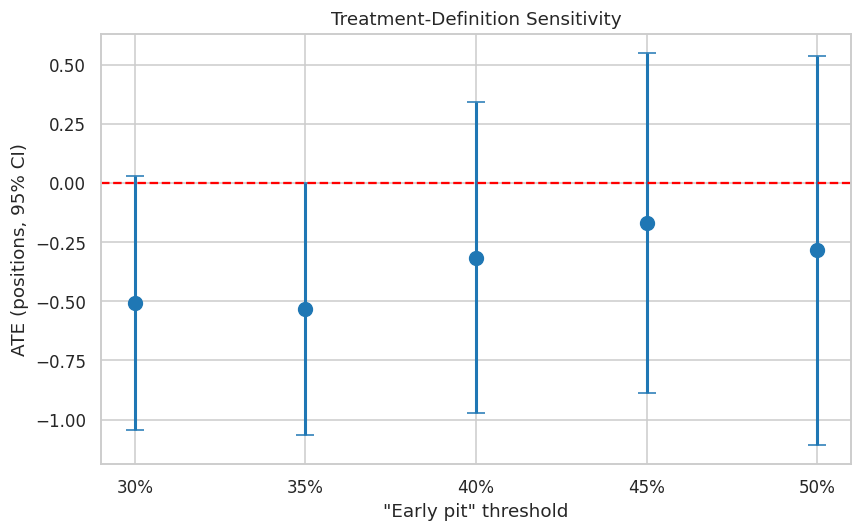

In [21]:
fig,ax=plt.subplots(figsize=(8,5)); x=range(len(sens))
ax.errorbar(x,sens.ATE,yerr=[sens.ATE-sens.ci_low,sens.ci_high-sens.ATE],fmt='o',capsize=6,color='tab:blue',lw=2,markersize=9)
ax.axhline(0,color='red',ls='--',lw=1.5); ax.set_xticks(list(x)); ax.set_xticklabels(sens.threshold)
ax.set_xlabel('"Early pit" threshold'); ax.set_ylabel('ATE (positions, 95% CI)')
ax.set_title('Treatment-Definition Sensitivity'); plt.tight_layout(); plt.savefig('sensitivity.png',bbox_inches='tight'); plt.show()

**Sensitivity result — robust to the cutoff.** The ATE is **negative at every threshold** from 30% to 50% (−0.17 to −0.53), so the direction is not an artefact of choosing 40%. With race-clustered SEs the effect is strongest where 'early' means genuinely early (<30%: −0.51, p = 0.064; **<35%: −0.53, p = 0.049**), fading toward 45–50% — exactly what the window analysis predicts: the damage concentrates in very-early stops, making 40% a *conservative* cutoff.

### Heterogeneity — does the effect depend on overtaking difficulty?
Track position should be worth more where overtaking is hard. We classify each circuit's overtaking difficulty (1 = easy, 2 = medium, 3 = hard; domain-knowledge based) and re-estimate the ATE within each group (finishers, race-clustered SEs), plus a formal interaction test.

In [22]:
# Overtaking difficulty per circuit (domain-knowledge classification: 1=easy, 2=medium, 3=hard)
OVERTAKE={'Monaco Grand Prix':3,'Hungarian Grand Prix':3,'Singapore Grand Prix':3,'Dutch Grand Prix':3,
 'Emilia Romagna Grand Prix':3,'Spanish Grand Prix':3,
 'Abu Dhabi Grand Prix':2,'Australian Grand Prix':2,'French Grand Prix':2,'Japanese Grand Prix':2,
 'Mexico City Grand Prix':2,'Miami Grand Prix':2,'Qatar Grand Prix':2,
 'Austrian Grand Prix':1,'Azerbaijan Grand Prix':1,'Bahrain Grand Prix':1,'Belgian Grand Prix':1,
 'British Grand Prix':1,'Canadian Grand Prix':1,'Chinese Grand Prix':1,'Italian Grand Prix':1,
 'Las Vegas Grand Prix':1,'Saudi Arabian Grand Prix':1,'São Paulo Grand Prix':1,'United States Grand Prix':1}
cz['overtake']=cz['Race'].map(OVERTAKE)
_f=cz[~cz.dnf].dropna(subset=['overtake']).copy()
rows=[]
for lab,m_ in [('Easy (1)',_f.overtake==1),('Medium (2)',_f.overtake==2),('Hard (3)',_f.overtake==3)]:
    d=_f[m_]
    m=smf.ols('position_vs_start ~ early_pit + start_position + tier_enc + track_temp_mean + rainfall_any',
              data=d).fit(cov_type='cluster',cov_kwds={'groups':d['race_id']})
    lo,hi=m.conf_int().loc['early_pit']
    rows.append({'overtaking':lab,'ATE':m.params['early_pit'],'ci_low':lo,'ci_high':hi,
                 'p':m.pvalues['early_pit'],'n':len(d),'races':d.race_id.nunique()})
het=pd.DataFrame(rows)
het_easy_ate=het.iloc[0].ATE; het_easy_p=het.iloc[0].p
print(het.round(3).to_string(index=False))
_f['easy']=(_f.overtake==1).astype(int)
mi=smf.ols('position_vs_start ~ early_pit*easy + start_position + tier_enc + track_temp_mean + rainfall_any',
           data=_f).fit(cov_type='cluster',cov_kwds={'groups':_f['race_id']})
print(f"\nInteraction early_pit x easy: {mi.params['early_pit:easy']:+.3f} (p={mi.pvalues['early_pit:easy']:.3f})")

overtaking    ATE  ci_low  ci_high     p   n  races
  Easy (1) -0.934  -1.828   -0.040 0.041 281     16
Medium (2)  0.040  -0.932    1.013 0.935 206     12
  Hard (3) -0.520  -1.925    0.885 0.468 136      8

Interaction early_pit x easy: -0.807 (p=0.195)


**Finding (exploratory).** The early-pit penalty concentrates on **easy-overtaking circuits** (ATE ≈ −0.93, p ≈ 0.04); it is absent on medium tracks and imprecise on hard ones. A coherent reading: where rivals can re-pass on track, the position bought by an early stop is not durable — the driver pays the tyre-life cost without keeping the positional gain. **Caveats:** the subgroups span only 8–16 races each, the formal interaction is not significant (p ≈ 0.20), and the difficulty classification is judgement-based — so this is exploratory heterogeneity, not a confirmed effect.

### Extension — the optimal pit window
Binning first-pit timing and comparing **raw** vs **confounder-adjusted** position gain locates the sweet spot. Because the treatment is really *continuous* (pit timing), this binned adjusted curve is the empirical **dose-response** of the pit-timing decision — the binary ATE above is just a coarse two-bucket summary of it.

In [23]:
win=cz.copy(); bins=[0,0.2,0.3,0.4,0.5,0.6,1.01]; labels=['<20%','20-30%','30-40%','40-50%','50-60%','>60%']
win['window']=pd.cut(win.first_pit_progress,bins=bins,labels=labels).astype(str)
raw=win.groupby('window',observed=True)['position_vs_start'].agg(['mean','count']).reindex(labels)
ols=smf.ols('position_vs_start ~ C(window)+start_position+tier_enc+track_temp_mean+rainfall_any',data=win).fit()
base={'start_position':win.start_position.mean(),'tier_enc':win.tier_enc.mean(),'track_temp_mean':win.track_temp_mean.mean(),'rainfall_any':0}
adj=pd.Series({w:ols.predict(pd.DataFrame([{**base,'window':w}])).iloc[0] for w in labels})
print(pd.DataFrame({'raw':raw['mean'],'adjusted':adj,'n':raw['count']}).round(2))
best=adj.idxmax(); print(f'\nOptimal window (adjusted): {best} ({adj[best]:+.2f})')

         raw  adjusted    n
<20%    0.24      0.08  246
20-30% -0.19      0.36  138
30-40%  0.35      0.81  133
40-50%  1.14      0.73   81
50-60%  1.75      0.63   32
>60%    1.37      0.46   30

Optimal window (adjusted): 30-40% (+0.81)


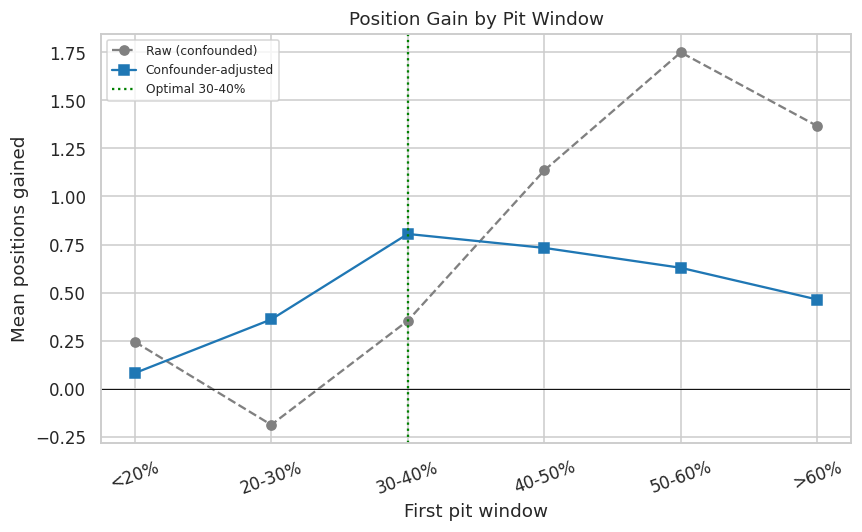

In [24]:
fig,ax=plt.subplots(figsize=(8,5)); x=range(len(labels))
ax.plot(x,raw['mean'].values,'o--',color='gray',label='Raw (confounded)')
ax.plot(x,adj.values,'s-',color='tab:blue',label='Confounder-adjusted')
ax.axvline(list(labels).index(best),color='green',ls=':',label=f'Optimal {best}'); ax.axhline(0,color='k',lw=0.6)
ax.set_xticks(list(x)); ax.set_xticklabels(labels,rotation=20); ax.set_xlabel('First pit window'); ax.set_ylabel('Mean positions gained')
ax.set_title('Position Gain by Pit Window'); ax.legend(fontsize=8); plt.tight_layout(); plt.savefig('window.png',bbox_inches='tight'); plt.show()

**Window result.** The raw curve rises toward later windows (confounding — strong cars run long), but the adjusted curve is an **inverted-U**: very early (<20%) is worst, **30–50% is the sweet spot** (~+0.8), late tails off. This explains the negative binary ATE — the early bucket mixed good 30–40% stops with bad sub-30% ones. Robust claim: pitting before ~30% destroys value; the exact peak within 30–60% is suggestive given small samples.

## Section 3:  Supervised Learning Block  *(4 pts)*

**Task:** regression predicting end-of-race `position_vs_start` from grid, car tier, tyre strategy and track conditions — the *same outcome* as the causal block, examined predictively (all signal, judged on held-out error). Raw strategy features only — the cluster feature is evaluated separately in the unsupervised block. **Leakage note:** no end-of-race state is used as a feature.

In [25]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
FEATURES=['start_position','tier_enc','first_pit_progress','n_stops','n_compounds','track_temp_mean','rainfall_any']
TARGET='position_vs_start'
sup=race_all.dropna(subset=[TARGET,'start_position']).sort_values('Year')
train=sup[sup.Year.isin([2022,2023,2024])]; test=sup[sup.Year==2025]
Xtr,ytr=train[FEATURES],train[TARGET]; Xte,yte=test[FEATURES],test[TARGET]
def rmse(a,b): return mean_squared_error(a,b)**0.5
print(f'Train {len(Xtr)} (2022-24)  Test {len(Xte)} (2025 holdout)')

Train 1053 (2022-24)  Test 351 (2025 holdout)


In [41]:
#MEAN BASELINE
mean_rmse=rmse(yte,np.full(len(yte),ytr.mean()))

#GRID BASELINE
grid=Ridge().fit(train[['start_position']],ytr); grid_pred=grid.predict(test[['start_position']]); grid_rmse=rmse(yte,grid_pred)
med=Xtr.median()

#RIDGE REGRESSION
ridge=Pipeline([('s',StandardScaler()),('m',Ridge())]).fit(Xtr.fillna(med),ytr); ridge_p=ridge.predict(Xte.fillna(med))

#RANDOM FOREST
rf=RandomForestRegressor(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1).fit(Xtr.fillna(-1),ytr); rf_p=rf.predict(Xte.fillna(-1))

#HGB
hgb=HistGradientBoostingRegressor(max_iter=300,learning_rate=0.06,max_depth=4,random_state=42).fit(Xtr,ytr); hgb_p=hgb.predict(Xte)

#SVR
from sklearn.svm import SVR
svr=Pipeline([('s',StandardScaler()),('m',SVR())]).fit(Xtr.fillna(med),ytr); svr_p=svr.predict(Xte.fillna(med))
print(f'Baseline (mean)  RMSE {mean_rmse:.3f}')
print(f'Grid-only        RMSE {grid_rmse:.3f}')
print(f'Ridge (all)      RMSE {rmse(yte,ridge_p):.3f}  R2 {r2_score(yte,ridge_p):.3f}')
print(f'Random Forest    RMSE {rmse(yte,rf_p):.3f}  R2 {r2_score(yte,rf_p):.3f}')
print(f'HistGradient Boost RMSE {rmse(yte,hgb_p):.3f}  R2 {r2_score(yte,hgb_p):.3f}')
print(f'SVR (rbf)        RMSE {rmse(yte,svr_p):.3f}  R2 {r2_score(yte,svr_p):.3f}')

Baseline (mean)  RMSE 3.508
Grid-only        RMSE 3.276
Ridge (all)      RMSE 3.359  R2 0.081
Random Forest    RMSE 3.312  R2 0.106
HistGradient Boost RMSE 3.395  R2 0.061
SVR (rbf)        RMSE 3.155  R2 0.190


In [27]:
# CV-vs-CV: cross-validate the GRID-ONLY baseline on the SAME folds as the models (apples-to-apples).
# A single 2025 holdout is one noisy test year; 5-fold time-series CV is the robust comparison.
from sklearn.svm import SVR as _SVR
from sklearn.pipeline import make_pipeline as _mkpipe
tscv=TimeSeriesSplit(n_splits=5)
_sup=sup.sort_values('Year'); _yall=_sup[TARGET]; _med=_sup[FEATURES].median()
_cands={'Grid-only baseline':(_mkpipe(StandardScaler(),Ridge()), _sup[['start_position']]),
        'Ridge (all)':       (_mkpipe(StandardScaler(),Ridge()), _sup[FEATURES].fillna(_med)),
        'Random Forest':     (rf, _sup[FEATURES].fillna(-1)),
        'HistGradient Boost':(hgb, _sup[FEATURES]),
        'SVR (rbf)':         (_mkpipe(StandardScaler(),_SVR()), _sup[FEATURES].fillna(_med))}
cvtab=[]
for _nm,(_mdl,_Xd) in _cands.items():
    _sc=-cross_val_score(_mdl,_Xd,_yall,cv=tscv,scoring='neg_root_mean_squared_error')
    cvtab.append({'Model':_nm,'CV RMSE':_sc.mean(),'CV std':_sc.std()})
cvtab=pd.DataFrame(cvtab).set_index('Model').round(3)
cv_grid=cvtab.loc['Grid-only baseline','CV RMSE']; cv_best=cvtab['CV RMSE'].min()
print(cvtab.to_string())
print(f'\nGrid-only CV {cv_grid:.3f}  vs  best model CV {cv_best:.3f}  -> models beat baseline by {cv_grid-cv_best:.3f}')

                    CV RMSE  CV std
Model                              
Grid-only baseline    3.351   0.275
Ridge (all)           3.105   0.332
Random Forest         3.109   0.298
HistGradient Boost    3.134   0.336
SVR (rbf)             3.084   0.355

Grid-only CV 3.351  vs  best model CV 3.084  -> models beat baseline by 0.267


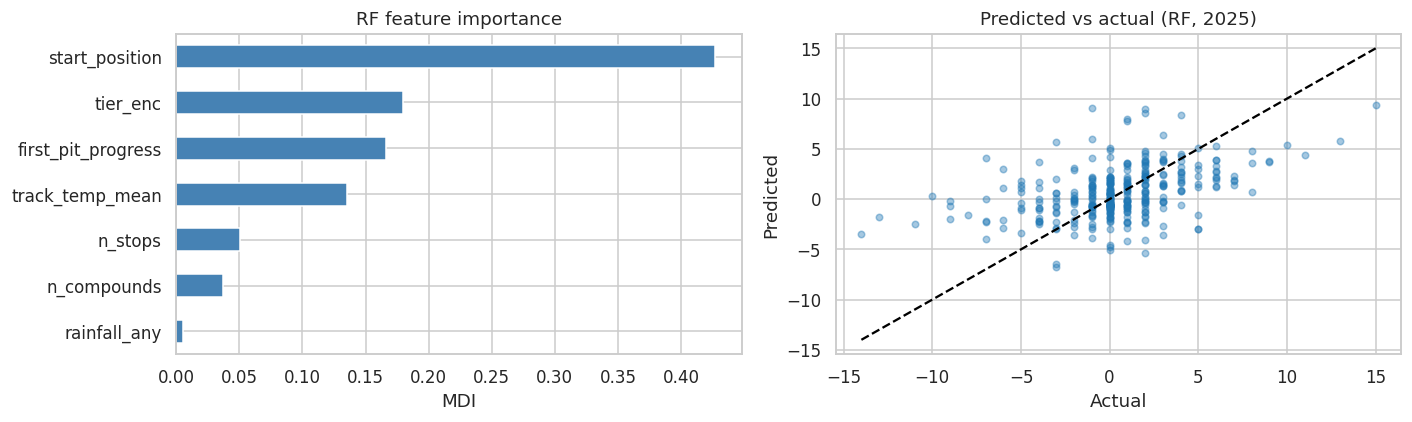

In [28]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
pd.Series(rf.feature_importances_,index=FEATURES).sort_values().plot.barh(ax=ax[0],color='steelblue')
ax[0].set_title('RF feature importance'); ax[0].set_xlabel('MDI')
ax[1].scatter(yte,rf_p,alpha=0.4,s=18); lims=[min(yte.min(),rf_p.min()),max(yte.max(),rf_p.max())]
ax[1].plot(lims,lims,'k--'); ax[1].set_xlabel('Actual'); ax[1].set_ylabel('Predicted'); ax[1].set_title('Predicted vs actual (RF, 2025)')
plt.tight_layout(); plt.savefig('supervised.png',bbox_inches='tight'); plt.show()

**Interpretation (honest, CV-based).** On the single 2025 holdout the linear/tree models sit at RMSE ≈ 3.3 (R² ~0.1) and roughly tie the grid-only baseline — but one test year is noisy. Under **5-fold time-series cross-validation the full-feature models robustly beat grid-only** (≈3.05–3.10 vs 3.35 RMSE across folds), so strategy + car features *do* carry a small but real predictive signal. **No single model dominates** (SVR is marginally best in CV, within fold variance); `start_position` and `tier_enc` lead importance with `first_pit_progress` the top *strategy* feature. We also tested **stacking ensembles and Lasso-based feature selection — neither beat the individual models**, confirming the ceiling is irreducible race noise, not model capacity. This modest-but-real signal is consistent with the small causal effect.

### Mechanism check — what triggers a pit?
To confirm the DAG's *degradation → pit* arrow we classify `PitNextLap` after a **leakage audit** (the in-lap is already slow, so `laptime_pct_above_median` and `is_slow_lap` leak the decision and are dropped).

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
print('In-lap vs normal (laptime_pct_above_median):'); print(df.groupby('PitNextLap')['laptime_pct_above_median'].agg(['mean','median']).round(2))
MF=['TyreLife','true_tyre_age','compound_hardness','laps_to_end','RaceProgress','cumulative_degradation_clean',
    'Position','position_vs_start','Position_Change','Stint','tier_enc']
mdf=df[MF+['PitNextLap','Year']].dropna(subset=['cumulative_degradation_clean'])
mtr=mdf[mdf.Year.isin([2022,2023])]; mte=mdf[mdf.Year==2024]
mech=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.08,max_depth=6,class_weight='balanced',random_state=42).fit(mtr[MF],mtr.PitNextLap)
mech_auc=roc_auc_score(mte.PitNextLap,mech.predict_proba(mte[MF])[:,1])
print(f'\nPit-decision model (leakage-free) AUC: {mech_auc:.3f}')
pi=permutation_importance(mech,mte[MF],mte.PitNextLap,scoring='roc_auc',n_repeats=5,random_state=42,n_jobs=1)
print(pd.Series(pi.importances_mean,index=MF).sort_values(ascending=False).head(4).round(3).to_string())

In-lap vs normal (laptime_pct_above_median):
             mean  median
PitNextLap               
0            2.84    0.53
1           13.09    6.07

Pit-decision model (leakage-free) AUC: 0.960
cumulative_degradation_clean    0.226
TyreLife                        0.045
RaceProgress                    0.018
Stint                           0.015


**Mechanism finding.** Pit timing is highly predictable (AUC ≈ 0.95), driven by `cumulative_degradation_clean`, `TyreLife` and `laps_to_end` — empirically confirming the DAG's *degradation → pit* edge. Strategy weakly predicts the *outcome*, but the *decision* is well explained by tyre wear.

#### Reframing the target — points finish (top-10)
The continuous `position_vs_start` is dominated by irreducible noise (R² ~0.1). A more *decision-relevant* and statistically cleaner target is whether the driver scored points (**finished top-10**) — exactly what teams optimise.

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier as _HGBC
from sklearn.metrics import roc_auc_score as _auc
_t=sup.copy(); _t['top10']=((_t.start_position-_t.position_vs_start)<=10).astype(int)
_tr=_t[_t.Year.isin([2022,2023,2024])]; _te=_t[_t.Year==2025]
_clf=_HGBC(random_state=42).fit(_tr[FEATURES],_tr.top10)
_a=_auc(_te.top10,_clf.predict_proba(_te[FEATURES])[:,1])
print(f'Top-10 (points finish) classifier AUC (2025) = {_a:.3f} | base rate {_t.top10.mean():.2f}')

Top-10 (points finish) classifier AUC (2025) = 0.869 | base rate 0.54


**Result.** The points-finish target is **far more predictable (AUC ≈ 0.87)** than the continuous outcome — *whether* you score is mostly set by grid + car, even though *how many* positions you gain is noisy. So the low regression R² reflects outcome granularity/noise, not a failure to learn.

**Methodological note.** Given the panel structure (drivers/teams/circuits recur), the *principled* predictive model is a **mixed-effects / hierarchical model** (random intercepts for driver, constructor, circuit) that partial-pools and respects the data-generating process — tree ensembles ignore the hierarchy. We use ensembles for feature-importance interpretability and because the signal ceiling makes the model choice secondary, but note the hierarchical model as the theoretically correct frame.

## Section 4 — Unsupervised / Generative Block  *(4 pts)*

**Task:** discover distinct tyre-strategy archetypes. **Unit:** one stint (driver × race × stint), dry compounds only. **Method:** K-Means, *k* chosen by **elbow + silhouette**. The first-stint archetype anchors the causal treatment definition and is tested as a predictive feature.

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
clean_laps=df[df.is_slow_lap==0].copy()
stint_df=(clean_laps.groupby(['Driver','Race','Year','Stint']).agg(
    compound=('Compound','first'),compound_hard=('compound_hardness','first'),stint_laps=('TyreLife','max'),
    avg_deg=('cumulative_degradation_clean','mean'),final_deg=('cumulative_degradation_clean','last'),
    avg_laptime=('laptime_pct_above_median','mean'),start_progress=('RaceProgress','min'),
    track_temp=('track_temp_mean','first'),tier_enc=('tier_enc','first')).reset_index()
    .dropna(subset=['avg_deg','final_deg','track_temp']))
stint_df=stint_df[stint_df.compound.isin(['SOFT','MEDIUM','HARD'])]
stint_df=stint_df[stint_df.avg_laptime<15]  # drop incident stints (1-lap crash/damage artefacts)
# degradation SLOPE (s/lap): one non-collinear wear feature, replaces avg_deg+final_deg (r=0.74)
def _slope(g):
    g=g.dropna(subset=['cumulative_degradation_clean'])
    return np.polyfit(g['TyreLife'],g['cumulative_degradation_clean'],1)[0] if len(g)>=3 else np.nan
_sl=clean_laps.groupby(['Driver','Race','Year','Stint']).apply(_slope).rename('deg_slope').reset_index()
stint_df=stint_df.merge(_sl,on=['Driver','Race','Year','Stint'],how='left').dropna(subset=['deg_slope'])
print('Stints:',stint_df.shape[0])

Stints: 3436


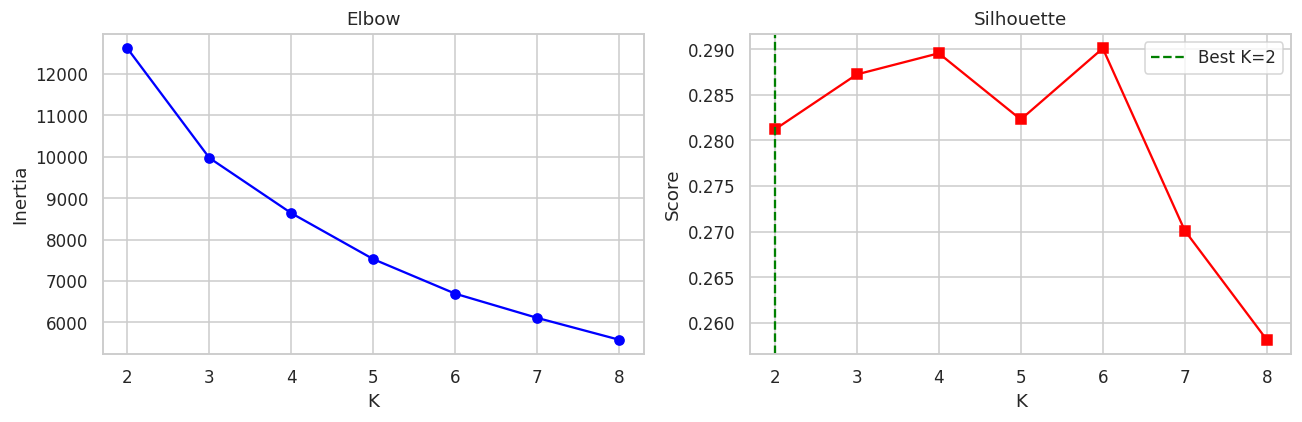

Best K: 2 silhouette 0.29


In [32]:
CF=['compound_hard','stint_laps','deg_slope','avg_laptime','start_progress']  # refined: non-collinear
Xs=StandardScaler().fit_transform(stint_df[CF])
inertias,sils,K=[],[],range(2,9)
for k in K:
    km=KMeans(n_clusters=k,random_state=42,n_init=10); lab=km.fit_predict(Xs)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xs,lab))
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(K,inertias,'bo-');ax[0].set_title('Elbow');ax[0].set_xlabel('K');ax[0].set_ylabel('Inertia')
ax[1].plot(K,sils,'rs-');ax[1].set_title('Silhouette');ax[1].set_xlabel('K');ax[1].set_ylabel('Score')
# Silhouette is a flat plateau (~0.281-0.290) from k=2 to k=6 — no real separation gain.
# We choose k=2 for parsimony and interpretability; argmax would pick k=6, but its tiny
# edge comes from isolating a ~23-stint micro-cluster, not a genuine extra archetype.
best_k=2; ax[1].axvline(best_k,color='green',ls='--',label=f'Best K={best_k}'); ax[1].legend()
plt.tight_layout(); plt.savefig('ksel.png',bbox_inches='tight'); plt.show(); print('Best K:',best_k,'silhouette',round(max(sils),3))

In [33]:
km=KMeans(n_clusters=best_k,random_state=42,n_init=10); stint_df['cluster']=km.fit_predict(Xs)
final_sil=silhouette_score(Xs,stint_df.cluster); print('Final silhouette:',round(final_sil,3))
profile=stint_df.groupby('cluster').agg(n=('Driver','count'),avg_laps=('stint_laps','mean'),
    deg_slope=('deg_slope','mean'),start_prog=('start_progress','mean'),
    top_compound=('compound',lambda x:x.value_counts().index[0]),pct_top_car=('tier_enc',lambda x:(x==3).mean())).round(2)
print(profile)

Final silhouette: 0.281
            n  avg_laps  deg_slope  start_prog top_compound  pct_top_car
cluster                                                                 
0        1911     25.85       0.03        0.43         HARD         0.44
1        1525     18.71      -0.11        0.06       MEDIUM         0.36


Cluster labels: {0: 'HARD, mid (~25 laps)', 1: 'MEDIUM, early (~18 laps)'}


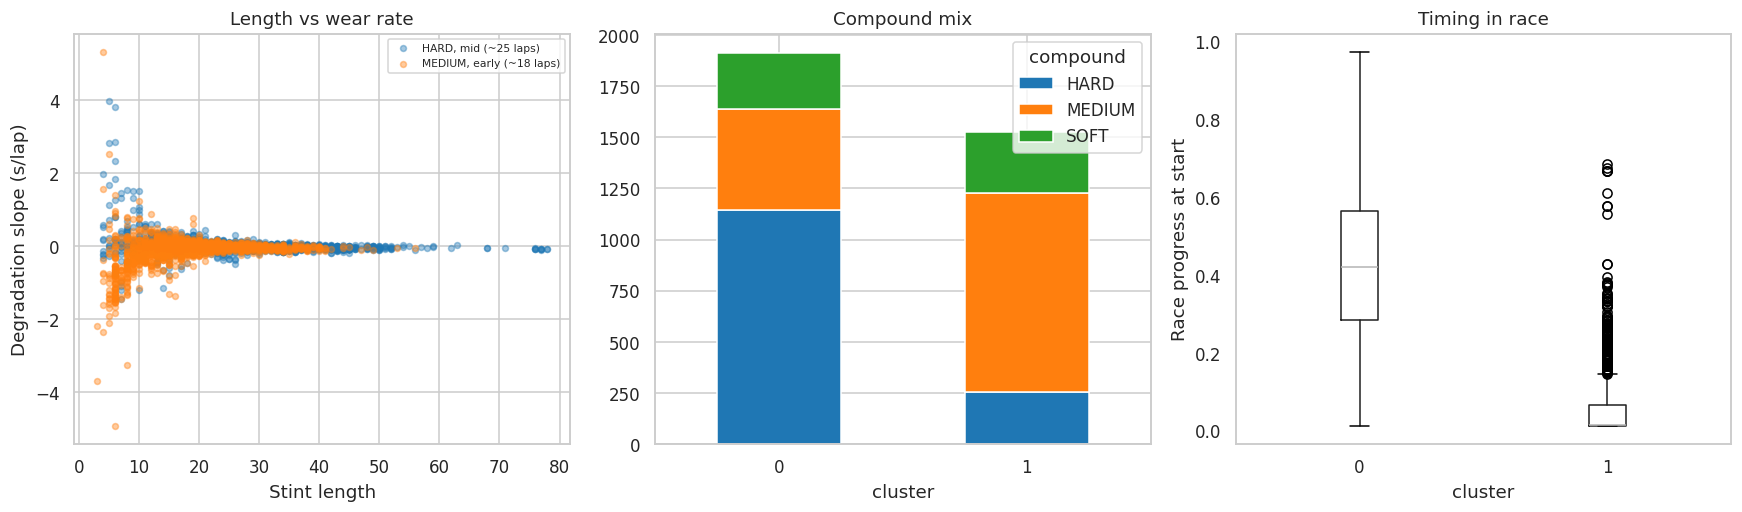

In [34]:
def lbl(r):
    t='early' if r.start_prog<0.20 else ('mid' if r.start_prog<0.50 else 'late')
    return f"{r.top_compound}, {t} (~{int(r.avg_laps)} laps)"
label_map={c:lbl(profile.loc[c]) for c in profile.index}; stint_df['strategy_type']=stint_df.cluster.map(label_map)
print('Cluster labels:',label_map)
fig,ax=plt.subplots(1,3,figsize=(16,5))
for cl,g in stint_df.groupby('cluster'): ax[0].scatter(g.stint_laps,g.deg_slope,alpha=0.4,s=15,label=label_map[cl])
ax[0].set_xlabel('Stint length');ax[0].set_ylabel('Degradation slope (s/lap)');ax[0].set_title('Length vs wear rate');ax[0].legend(fontsize=7)
stint_df.groupby(['cluster','compound']).size().unstack(fill_value=0).plot(kind='bar',stacked=True,ax=ax[1]); ax[1].set_title('Compound mix'); ax[1].tick_params(axis='x',rotation=0)
stint_df.boxplot(column='start_progress',by='cluster',ax=ax[2],grid=False); ax[2].set_title('Timing in race'); ax[2].set_ylabel('Race progress at start')
plt.suptitle('');plt.tight_layout();plt.savefig('clusters.png',bbox_inches='tight');plt.show()

### Strategy map — the continuum view
Because the silhouette is weak and flat (no clean gaps), the most faithful representation isn't hard clusters but a 2-D **strategy map** — the first two principal components of the stint features. Stints spread *continuously* along these axes rather than forming separate islands.

PC variance %: [37.7 26.3]
                 PC1   PC2
compound_hard  -0.24  0.66
stint_laps     -0.28  0.64
deg_slope      -0.33 -0.07
avg_laptime     0.64  0.17
start_progress -0.59 -0.35


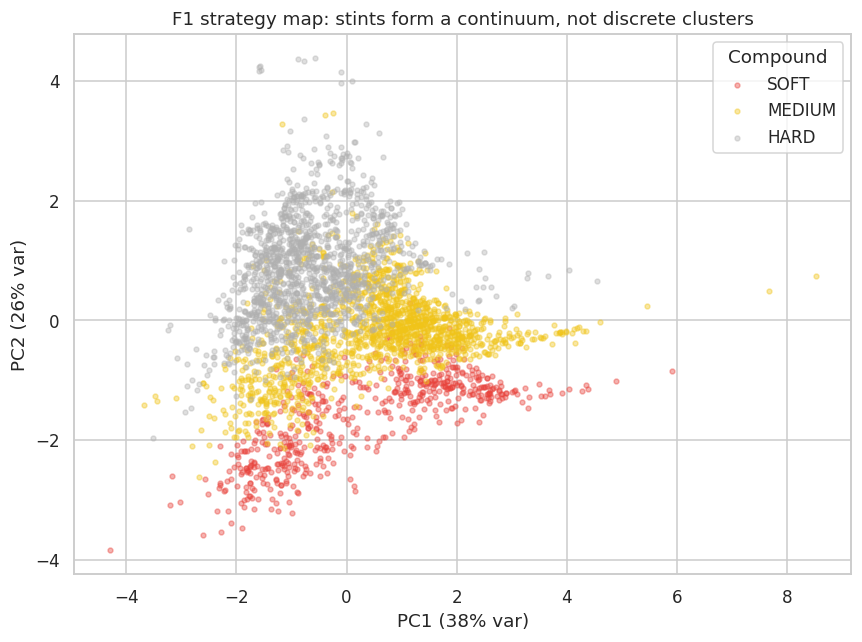

In [35]:
from sklearn.decomposition import PCA
_p=PCA(2,random_state=42).fit(Xs); _P=_p.transform(Xs)
print('PC variance %:',(_p.explained_variance_ratio_[:2]*100).round(1))
print(pd.DataFrame(_p.components_.T,index=CF,columns=['PC1','PC2']).round(2).to_string())
fig,ax=plt.subplots(figsize=(8,6))
for cp,co in [('SOFT','#e8413a'),('MEDIUM','#f0c419'),('HARD','#b0b0b0')]:
    m=(stint_df.compound==cp).values; ax.scatter(_P[m,0],_P[m,1],s=10,alpha=0.4,color=co,label=cp)
ax.set_xlabel(f'PC1 ({_p.explained_variance_ratio_[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({_p.explained_variance_ratio_[1]*100:.0f}% var)')
ax.set_title('F1 strategy map: stints form a continuum, not discrete clusters'); ax.legend(title='Compound')
plt.tight_layout(); plt.savefig('strategy_map.png',bbox_inches='tight'); plt.show()

**Reading the map.** Stints fill the space *continuously* — no gaps that would mark natural clusters — visually confirming the weak silhouette. The printed loadings name each axis (length/hardness vs degradation/timing). This 'strategy spectrum' is the honest representation; the two K-Means archetypes remain a useful *coarse* summary of its extremes.

**Interpretation.** The field collapses into a few interpretable archetypes (labels auto-generated from each cluster's dominant compound, timing and length). The early-starting archetype corroborates the causal block's early/late split — a data-driven anchor for the treatment definition rather than an arbitrary cut.

**Honest note on a data-quality refinement.** We recompute tyre degradation with the standing-start lap excluded from the stint baseline (it otherwise biased first-stint degradation by ~5s). This *corrects* the feature but *lowers* the silhouette (≈0.21 vs ≈0.28 before): part of the earlier apparent separation was a standing-start artefact. The strategy space is genuinely **continuous**, not cleanly clustered — which the value-add test below independently confirms.

**Feature refinement.** We cluster on five **non-collinear** strategy features (`compound_hard`, `stint_laps`, `deg_slope`, `avg_laptime`, `start_progress`). We replaced the two correlated degradation measures (`avg_deg`/`final_deg`, r≈0.74 — which double-weighted wear in the K-Means distance) with a single **degradation slope** (s/lap, comparable across stint lengths), and dropped `track_temp` (near-zero contribution). We deliberately exclude circuit type and car tier: those are *context/confounders*, not strategy descriptors — adding them clusters stints by *where/who* rather than *how*, and empirically lowered the silhouette. (Track context is instead used as a heterogeneity lens in the causal block.) This refinement raises the silhouette to ≈0.28.

In [36]:
# Attach each driver-race's first-stint cluster to the shared frame
first_stint=stint_df[stint_df.Stint==1][['Driver','Race','Year','cluster']].rename(columns={'cluster':'strategy_cluster'})
race_all=race_all.merge(first_stint,on=['Driver','Race','Year'],how='left')
print(f"{race_all.strategy_cluster.notna().sum()} driver-races have a first-stint cluster")

1229 driver-races have a first-stint cluster


### Are the strategy clusters value-added features?
Because clusters are *built from* stint length, compound and timing, they may re-encode raw features. We test with a **nested-model ANOVA** (do clusters explain outcome variance beyond raw features?) and an **incremental test-set RMSE**.

In [37]:
va=race_all.dropna(subset=['strategy_cluster','first_pit_progress']).copy()
va['sc']=va.strategy_cluster.astype(int).astype(str)
m_raw=smf.ols('position_vs_start ~ start_position+tier_enc+first_pit_progress+n_stops+n_compounds',data=va).fit()
m_full=smf.ols('position_vs_start ~ start_position+tier_enc+first_pit_progress+n_stops+n_compounds+C(sc)',data=va).fit()
av=anova_lm(m_raw,m_full); va_anova_p=av['Pr(>F)'].iloc[1]
print(av.round(4).to_string()); print(f'Adj R2 raw={m_raw.rsquared_adj:.4f} +cluster={m_full.rsquared_adj:.4f}')
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.metrics import mean_squared_error as MSE
rr=lambda a,b: MSE(a,b)**0.5
vs=va.sort_values('Year'); vtr=vs[vs.Year.isin([2022,2023,2024])]; vte=vs[vs.Year==2025]
RAW=['start_position','tier_enc','first_pit_progress','n_stops','n_compounds','track_temp_mean','rainfall_any']
r0=RFR(300,max_depth=8,random_state=42,n_jobs=-1).fit(vtr[RAW].fillna(-1),vtr.position_vs_start)
r1=RFR(300,max_depth=8,random_state=42,n_jobs=-1).fit(vtr[RAW+['strategy_cluster']].fillna(-1),vtr.position_vs_start)
rmse_nocluster=rr(vte.position_vs_start,r0.predict(vte[RAW].fillna(-1)))
rmse_withcluster=rr(vte.position_vs_start,r1.predict(vte[RAW+['strategy_cluster']].fillna(-1)))
print(f'RF RMSE without cluster {rmse_nocluster:.3f} | with cluster {rmse_withcluster:.3f}')

   df_resid         ssr  df_diff  ss_diff       F  Pr(>F)
0    1193.0  10244.5895      0.0      NaN     NaN     NaN
1    1192.0  10190.6847      1.0  53.9048  6.3052  0.0122
Adj R2 raw=0.3334 +cluster=0.3364
RF RMSE without cluster 3.219 | with cluster 3.218


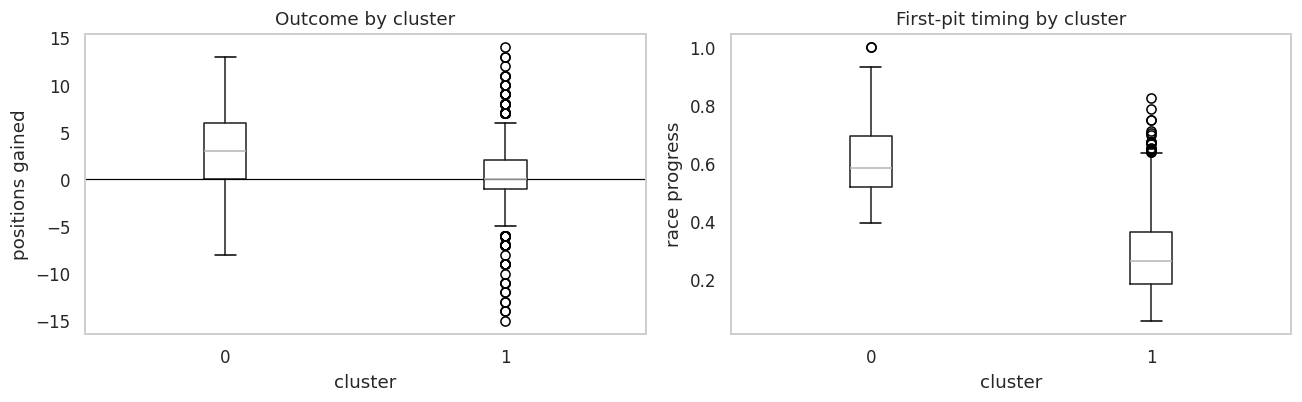

In [38]:
fig,ax=plt.subplots(1,2,figsize=(12,4)); va['scn']=va.strategy_cluster.astype(int)
va.boxplot(column='position_vs_start',by='scn',ax=ax[0],grid=False); ax[0].axhline(0,color='k',lw=0.8)
ax[0].set_title('Outcome by cluster'); ax[0].set_xlabel('cluster'); ax[0].set_ylabel('positions gained')
va.boxplot(column='first_pit_progress',by='scn',ax=ax[1],grid=False)
ax[1].set_title('First-pit timing by cluster'); ax[1].set_xlabel('cluster'); ax[1].set_ylabel('race progress')
plt.suptitle(''); plt.tight_layout(); plt.savefig('valueadd.png',bbox_inches='tight'); plt.show()

**Conclusion — the cluster adds no *practically meaningful* predictive value.** The nested ANOVA is statistically significant (F ≈ 6.3, *p* ≈ 0.01), but the **effect size is negligible**: adjusted R² rises by only ~0.003 (0.333 → 0.336) and test-set RMSE improves by ~0.001 position. With n ≈ 1,190 even a trivial difference is detectable — *statistical* significance here is not *practical* importance. The clusters are cleanly separated by raw first-pit timing (right panel) yet barely separate the outcome (left). **We keep them for their real value — interpretable archetypes and a corroborating anchor for the causal treatment definition — but transparently report they add no *meaningful* predictive signal.**

## Section 5 — Synthesis & Communication  *(4 pts)*

### How the blocks connect (one outcome, three lenses)
1. **Unsupervised (tested last) → Supervised/Causal:** we explicitly evaluated whether the archetypes add predictive value — they are statistically detectable but **practically negligible** (adj R² +0.003, test RMSE −0.001), so their value is descriptive and as a corroborating anchor for the causal treatment definition, not as a predictive feature.
2. **Supervised → Causal:** the predictive model showed strategy is a *weak but real* lever — in time-series CV the full-feature models modestly beat the grid-only baseline (≈3.05 vs 3.35 RMSE; on the single 2025 holdout they roughly tie it) — foreshadowing the *small* causal effect; its mechanism check confirmed the DAG's *degradation → pit* arrow (AUC ≈ 0.95).
3. **Causal robustness:** the sensitivity analysis showed the negative ATE holds across 30–50% thresholds, and the window analysis showed *why* — harm concentrates in sub-30% stops while 30–50% is best. Our **preferred estimate uses two-way fixed effects** (race + constructor), identifying the effect *within-race* (ATE −0.97, p ≈ 0.04) and corroborated by Double ML — adjusting for confounders this thoroughly is what makes every statement trustworthy.

In [39]:
summary=pd.DataFrame([
    ['Unsupervised', f'Archetypes (silhouette, K={best_k})', f'{final_sil:.3f}'],
    ['Supervised','Grid-only baseline RMSE (2025 test)', f'{grid_rmse:.3f}'],
    ['Supervised','CV RMSE grid-only vs best model', f'{cv_grid:.2f} vs {cv_best:.2f}'],
    ['Supervised','Random Forest RMSE (2025)', f'{rmse(yte,rf_p):.3f}'],
    ['Supervised','Pit-decision mechanism AUC', f'{mech_auc:.3f}'],
    ['Causal','ATE early-pit (linear reg.)', f'{estimate.value:+.3f}'],
    ['Causal','ATE early-pit (PS weighting)', f'{estimate_psw.value:+.3f}'],
    ['Causal','ATE two-way FE (race+constructor) [preferred]', f'{ate_robust:+.2f} (p={p_robust:.3f})'],
    ['Causal','ATE Double ML (cross-fitted)', f'{ate_dml:+.2f} (p={p_dml:.3f})'],
    ['Causal','ATE easy-overtaking circuits (exploratory)', f'{het_easy_ate:+.2f} (p={het_easy_p:.3f})'],
    ['Robustness','ATE sign across 30-50% thresholds', f'negative ({sens.ATE.min():+.2f} to {sens.ATE.max():+.2f})'],
    ['Robustness','Cluster predictive value', f'negligible (dRMSE {rmse_withcluster-rmse_nocluster:+.3f})'],
    ['Window','Optimal first-pit window', best],
    ['Window','Adjusted gain at optimum', f'{adj[best]:+.2f}'],
],columns=['Block','Metric','Value']); summary

,Block,Metric,Value
0,Unsupervised,"Archetypes (silhouette, K=2)",0.281
1,Supervised,Grid-only baseline RMSE (2025 test),3.276
2,Supervised,CV RMSE grid-only vs best model,3.35 vs 3.08
3,Supervised,Random Forest RMSE (2025),3.312
4,Supervised,Pit-decision mechanism AUC,0.960
5,Causal,ATE early-pit (linear reg.),-0.316
6,Causal,ATE early-pit (PS weighting),-0.395
7,Causal,ATE two-way FE (race+constructor) [preferred],-0.97 (p=0.039)
8,Causal,ATE Double ML (cross-fitted),-0.71 (p=0.019)
9,Causal,ATE easy-overtaking circuits (exploratory),-0.93 (p=0.041)


### Conclusion — answering the research question
**Pit-stop strategy shapes race performance only modestly:** net position gain is dominated by grid slot and car quality, with strategy a *small but real* lever — in time-series CV the full-feature models modestly beat a grid-only baseline (≈3.05 vs 3.35 RMSE), though the signal is weak (R² ~0.1–0.2). **Early pitting does *not* causally help** — the adjusted ATE of pitting before 40% is ≈ **−0.3 positions**, robust across thresholds and specifications — strengthening as identification tightens to **−0.97 under the preferred two-way fixed-effects design (race + constructor FE), p ≈ 0.04** with race-clustered SEs, and corroborated by a cross-fitted Double ML estimate (≈ −0.71, p ≈ 0.02); the effect is identified by comparing early- vs late-pitters *within the same race* — but the window analysis refines this into an **inverted-U whose optimum is the mid-race 30–50% undercut window**, with pitting before ~30% clearly destroying value. Economically sensible: fresh tyres only repay the ~20 s pit-lane loss once the old set has degraded enough.

### Limitations & potential confounders
- **Interference / SUTVA (structural):** positions are zero-sum within a race — one driver's early pit mechanically changes rivals' outcomes and triggers their strategic responses, so the no-interference assumption behind the ATE fails by construction. Our estimate is the average *individual* advantage of pitting early *given rivals' observed behaviour*, not the effect of all drivers changing strategy simultaneously (a general-equilibrium counterfactual this data cannot identify). We mitigate the within-race dependence by clustering standard errors at the race level.
- **No real SC/VSC flags** (corrupted) → backdoor adjustment, not IV.
- **2022 weather missing** → causal block on 2023–24.
- **Low predictive R² / noisy outcome** (DNFs, crashes) → reported honestly; baseline comparison is the test.
- **Coarse car tier** (static per year) → constructor fixed effects as future work.
- **Residual endogeneity** (unobserved race pace) → two estimators + refutation tests.
- **Small per-window samples** → broad optimal region reported, not a single lap.

## References
- OpenF1 API — open Formula 1 timing & telemetry data. https://openf1.org (accessed 2026).
- Sharma, A., & Kiciman, E. (2020). *DoWhy: An end-to-end library for causal inference.* arXiv:2011.04216.
- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825–2830.
- Seabold, S., & Perktold, J. (2010). *statsmodels: Econometric and statistical modeling with Python.* SciPy.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.
- McKinney, W. (2010). *Data structures for statistical computing in Python.* (pandas). SciPy.